## Volver a correr con Métricas

Mejores parámetros: {'lambda': 10, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Log Loss: 0.1390
Matriz de confusión:
[[9631   99]
 [ 430  437]]
Accuracy: 0.9501
AUC: 0.9424


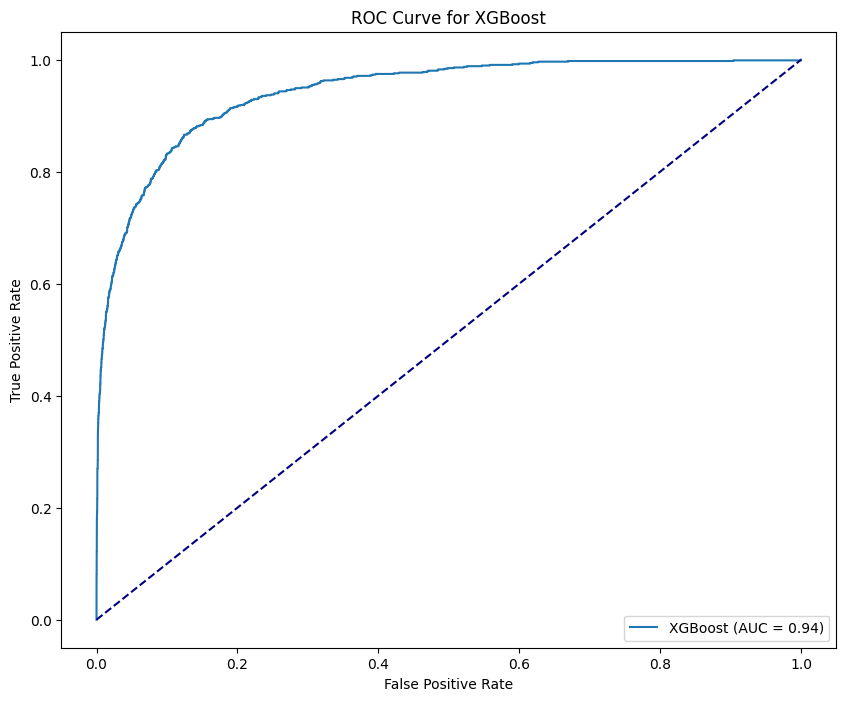

In [4]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir datos para entrenar y validar
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Definir el modelo de XGBoost con GridSearch y L2 Regularization (lambda)
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss')
param_grid = {
    'lambda': [0.1, 1, 10],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, scoring='neg_log_loss', cv=cv)
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo y sus parámetros
best_xgb = grid_search.best_estimator_
best_params = grid_search.best_params_

# Mostrar los mejores parámetros encontrados
print("Mejores parámetros:", best_params)

# Predicción en el conjunto de validación
y_val_proba = best_xgb.predict_proba(X_val)[:, 1]
y_val_pred = best_xgb.predict(X_val)

# Cálculo de la métrica log loss
log_loss_val = log_loss(y_val, y_val_proba)
print(f"Log Loss: {log_loss_val:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_val, y_val_pred)
print("Matriz de confusión:")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy: {accuracy:.4f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

In [13]:
# Extraer los resultados del GridSearchCV
cv_results = grid_search.cv_results_

# Crear un DataFrame con los parámetros y el log loss para cada combinación
results_df = pd.DataFrame({
    'lambda': cv_results['param_lambda'],
    'max_depth': cv_results['param_max_depth'],
    'learning_rate': cv_results['param_learning_rate'],
    'n_estimators': cv_results['param_n_estimators'],
    'mean_log_loss': -cv_results['mean_test_score'],  # Negar para obtener log loss positivo
    'std_log_loss': cv_results['std_test_score']
})

# Si prefieres verlo en Jupyter, simplemente ejecuta esta línea:
results_df

,lambda,max_depth,learning_rate,n_estimators,mean_log_loss,std_log_loss
80,10.0,7,0.20,200,0.138293,0.001186
44,1.0,7,0.10,200,0.139629,0.000837
17,0.1,7,0.10,200,0.139994,0.000990
50,1.0,5,0.20,200,0.140291,0.001813
52,1.0,7,0.20,100,0.140598,0.000962
...,...,...,...,...,...,...
30,1.0,5,0.01,50,0.247313,0.000990
57,10.0,5,0.01,50,0.250816,0.000971
0,0.1,3,0.01,50,0.258285,0.000829
27,1.0,3,0.01,50,0.258566,0.000826


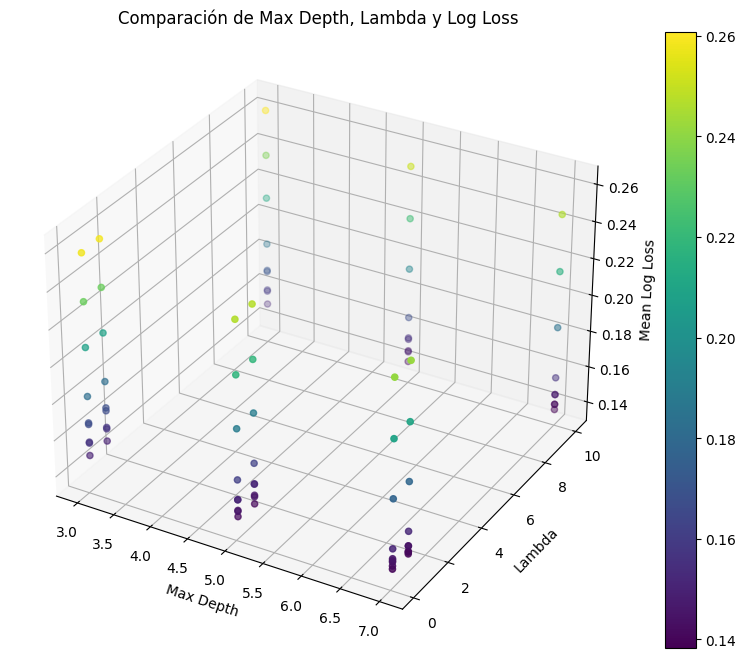

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Crear una figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Definir los ejes
x = results_df['max_depth']
y = results_df['lambda']
z = results_df['mean_log_loss']

# Graficar los puntos
sc = ax.scatter(x, y, z, c=z, cmap='viridis', marker='o')

# Etiquetas de los ejes
ax.set_xlabel('Max Depth')
ax.set_ylabel('Lambda')
ax.set_zlabel('Mean Log Loss')

# Añadir barra de colores para la escala del log loss
plt.colorbar(sc)

# Título del gráfico
plt.title('Comparación de Max Depth, Lambda y Log Loss')

# Mostrar el gráfico
plt.show()


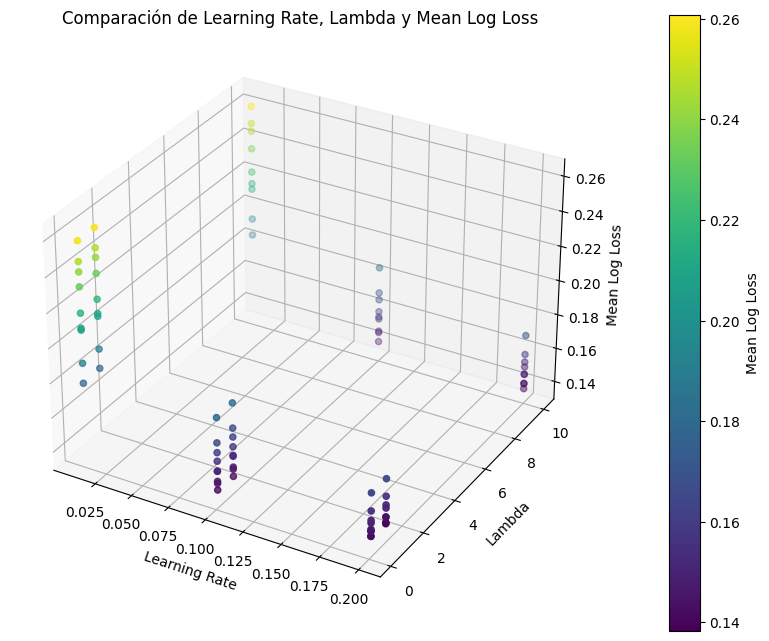

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Crear la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extraer los valores para cada eje
learning_rate = results_df['learning_rate']
_lambda = results_df['lambda']
mean_log_loss = results_df['mean_log_loss']

# Crear la gráfica de dispersión
sc = ax.scatter(learning_rate, _lambda, mean_log_loss, c=mean_log_loss, cmap='viridis', marker='o')

# Etiquetas de los ejes
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Lambda')
ax.set_zlabel('Mean Log Loss')

# Añadir la barra de colores
cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('Mean Log Loss')

# Título
plt.title('Comparación de Learning Rate, Lambda y Mean Log Loss')

# Mostrar la gráfica
plt.show()

## 2. Mejora de gridsearch

c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores parámetros: {'lambda': 3.0000000000000004, 'learning_rate': 0.15000000000000002, 'max_depth': 8, 'n_estimators': 200}
Log Loss: 0.1376
Matriz de confusión:
[[9625  105]
 [ 425  442]]
Accuracy: 0.9500
AUC: 0.9437


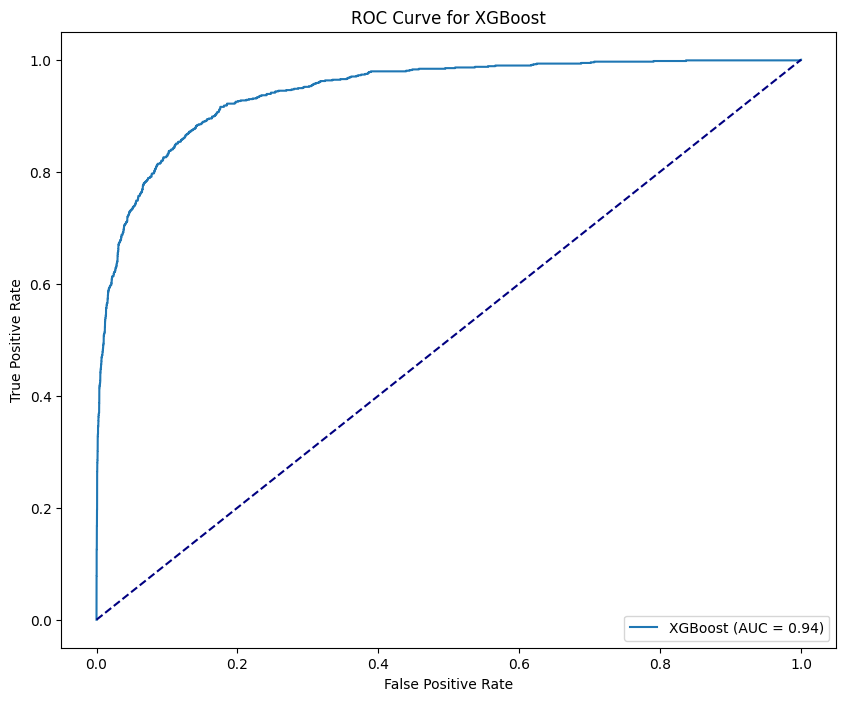

In [18]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt
import numpy as np

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir datos para entrenar y validar
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Definir el modelo de XGBoost con GridSearch y L2 Regularization (lambda)
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss')

# Ajustar los rangos de hiperparámetros
param_grid = {
    'max_depth': list(range(5, 9, 1)),  # Rango de 5 a 8 con step 1
    'learning_rate': np.arange(0.1, 0.35, 0.05),  # Rango de 0.1 a 0.3 con step 0.05
    'lambda': np.arange(0.1, 3.1, 0.1),  # Rango de 0.1 a 3 con step 0.1
    'n_estimators': [200]  # Fijo para n_estimators
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, scoring='neg_log_loss', cv=cv)
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo y sus parámetros
best_xgb = grid_search.best_estimator_
best_params = grid_search.best_params_

# Mostrar los mejores parámetros encontrados
print("Mejores parámetros:", best_params)

# Predicción en el conjunto de validación
y_val_proba = best_xgb.predict_proba(X_val)[:, 1]
y_val_pred = best_xgb.predict(X_val)

# Cálculo de la métrica log loss
log_loss_val = log_loss(y_val, y_val_proba)
print(f"Log Loss: {log_loss_val:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_val, y_val_pred)
print("Matriz de confusión:")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy: {accuracy:.4f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

Mean Log Loss: 0.1375
Standard Deviation of Log Loss: 0.0046
Log Loss en validación: 0.1381
Matriz de confusión:
[[9633   97]
 [ 445  422]]
Accuracy: 0.9489
AUC: 0.9447


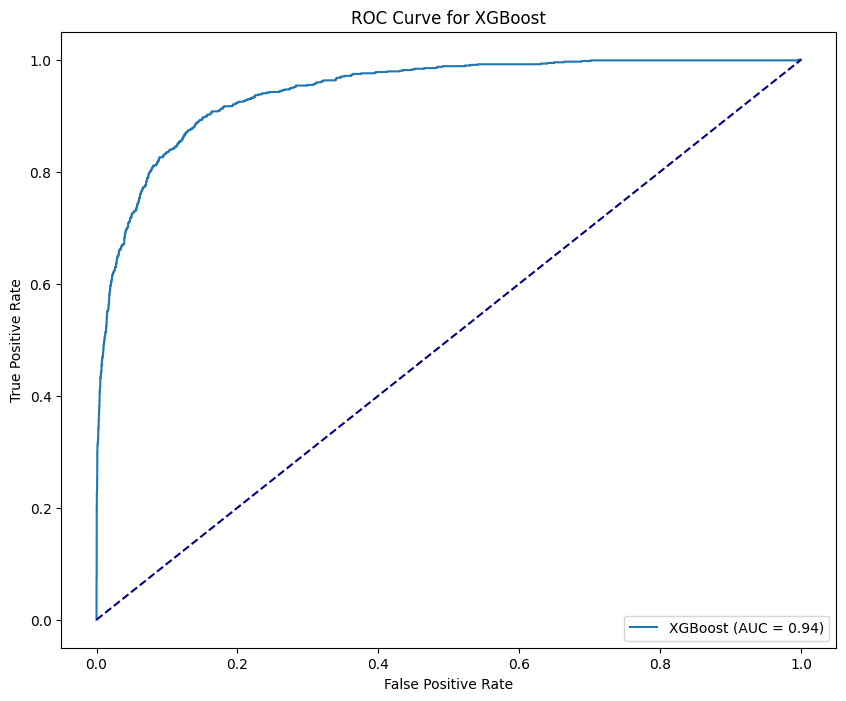

In [24]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir datos para entrenar y validar
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Definir el modelo de XGBoost con los hiperparámetros especificados
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=9,
    learning_rate=0.15,
    reg_lambda=3,
    n_estimators=100
)

# Definir el número de folds para cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Realizar validación cruzada y calcular la métrica log loss
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='neg_log_loss')

# Imprimir el log loss medio y la desviación estándar
mean_log_loss = -np.mean(cv_scores)  # Negamos para obtener el log loss positivo
std_log_loss = np.std(cv_scores)
print(f"Mean Log Loss: {mean_log_loss:.4f}")
print(f"Standard Deviation of Log Loss: {std_log_loss:.4f}")

# Entrenar el modelo final en todo el conjunto de entrenamiento
xgb_model.fit(X_train, y_train)

# Predicción en el conjunto de validación
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred = xgb_model.predict(X_val)

# Cálculo de la métrica log loss en el conjunto de validación
log_loss_val = log_loss(y_val, y_val_proba)
print(f"Log Loss en validación: {log_loss_val:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_val, y_val_pred)
print("Matriz de confusión:")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy: {accuracy:.4f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

## Gridsearch de estimators

Mejor número de estimadores (n_estimators): 190
Log Loss: 0.1370
Matriz de confusión:
[[9630  100]
 [ 427  440]]
Accuracy: 0.9503
AUC: 0.9456


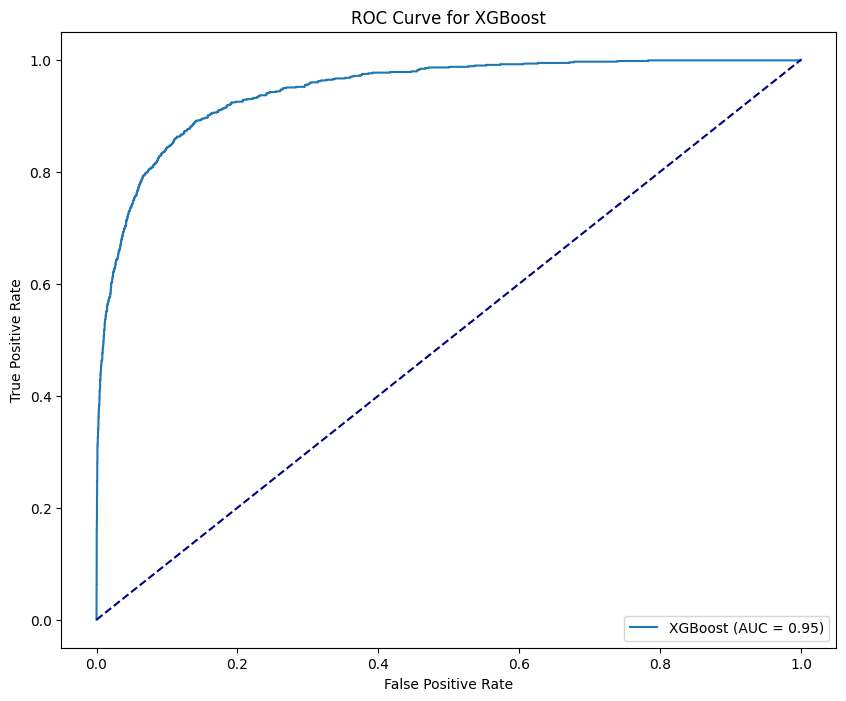

In [25]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir datos para entrenar y validar
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Definir el modelo de XGBoost con los hiperparámetros fijos
xgb_model = XGBClassifier(objective='binary:logistic', 
                          eval_metric='logloss', 
                          max_depth=9, 
                          learning_rate=0.15, 
                          reg_lambda=3)

# Definir la búsqueda del mejor n_estimators (50 a 200 en pasos de 10)
param_grid = {
    'n_estimators': list(range(50, 201, 10))
}

# Cross-validation con 10 folds
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, scoring='neg_log_loss', cv=cv)
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo y sus parámetros
best_xgb = grid_search.best_estimator_
best_params = grid_search.best_params_

# Mostrar los mejores parámetros encontrados
print("Mejor número de estimadores (n_estimators):", best_params['n_estimators'])

# Predicción en el conjunto de validación
y_val_proba = best_xgb.predict_proba(X_val)[:, 1]
y_val_pred = best_xgb.predict(X_val)

# Cálculo de la métrica log loss
log_loss_val = log_loss(y_val, y_val_proba)
print(f"Log Loss: {log_loss_val:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_val, y_val_pred)
print("Matriz de confusión:")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy: {accuracy:.4f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

In [26]:
import pandas as pd
from datetime import datetime

# Cargar el archivo de prueba
test_data = pd.read_csv('hoteles-prueba-limpio-normalizado.csv')

# Extraer la columna "id" y preparar los datos para predicción
test_ids = test_data['id']
X_test_data = test_data.drop(columns=['id'])

# Generar las probabilidades de predicción usando el mejor modelo de XGBoost (best_xgb)
y_pred_proba_test = best_xgb.predict_proba(X_test_data)[:, 1]

# Crear el archivo con timestamp
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M")
file_name = f'kaggle_submission_{timestamp}.csv'
kaggle_submission = pd.DataFrame({'id': test_ids, 'prob': y_pred_proba_test})

# Guardar el archivo para Kaggle
kaggle_submission.to_csv(file_name, index=False)

print(f"Archivo '{file_name}' creado con éxito para Kaggle.")

Archivo 'kaggle_submission_2024_10_19_19_27.csv' creado con éxito para Kaggle.


In [28]:
import pandas as pd

# Extraer los resultados del GridSearchCV
cv_results = grid_search.cv_results_

# Crear un DataFrame con los parámetros y el log loss para cada combinación
results_df = pd.DataFrame({
    'n_estimators': cv_results['param_n_estimators'],
    'mean_log_loss': -cv_results['mean_test_score'],  # Negar para obtener log loss positivo
    'std_log_loss': cv_results['std_test_score']
})

# Si prefieres verlo en Jupyter, simplemente ejecuta esta línea:
results_df

,n_estimators,mean_log_loss,std_log_loss
0,50,0.142194,0.004195
1,60,0.140653,0.004129
2,70,0.139634,0.004488
3,80,0.138734,0.004684
4,90,0.138097,0.004570
5,100,0.137450,0.004571
6,110,0.136935,0.004297
7,120,0.136630,0.004219
8,130,0.136358,0.004028
9,140,0.136221,0.003957


## Sin Cross Validation

Log Loss: 0.1354
Matriz de confusión:
[[9636   94]
 [ 419  448]]
Accuracy: 0.9516
AUC: 0.9466


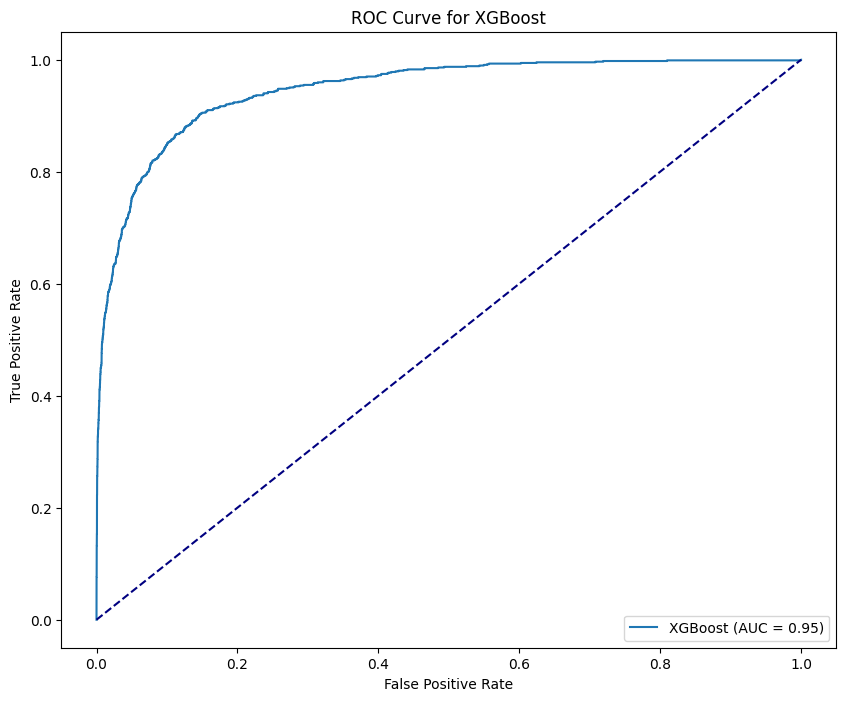

In [40]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir datos para entrenar y validar
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Definir el modelo de XGBoost con los hiperparámetros fijos
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=9,
    learning_rate=0.15,
    reg_lambda=4,
    n_estimators=190
)

# Entrenar el modelo sin validación cruzada
xgb_model.fit(X_train, y_train)

# Predicción en el conjunto de validación
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred = xgb_model.predict(X_val)

# Cálculo de la métrica log loss
log_loss_val = log_loss(y_val, y_val_proba)
print(f"Log Loss: {log_loss_val:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_val, y_val_pred)
print("Matriz de confusión:")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy: {accuracy:.4f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

In [42]:
import pandas as pd
from datetime import datetime

# Cargar el archivo de prueba
test_data = pd.read_csv('hoteles-prueba-limpio-normalizado.csv')

# Extraer la columna "id" y preparar los datos para predicción
test_ids = test_data['id']
X_test_data = test_data.drop(columns=['id'])

# Generar las probabilidades de predicción usando el modelo entrenado
y_pred_proba_test = xgb_model.predict_proba(X_test_data)[:, 1]

# Crear el archivo con timestamp
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M")
file_name = f'kaggle_submission_{timestamp}.csv'
kaggle_submission = pd.DataFrame({'id': test_ids, 'prob': y_pred_proba_test})

# Guardar el archivo para Kaggle
kaggle_submission.to_csv(file_name, index=False)

print(f"Archivo '{file_name}' creado con éxito para Kaggle.")

Archivo 'kaggle_submission_2024_10_19_19_38.csv' creado con éxito para Kaggle.


## Nuevo test hiperparámetros

c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores parámetros: {'learning_rate': 0.25000000000000006, 'n_estimators': 195, 'reg_lambda': 4.300000000000001}
Log Loss: 0.1408
Matriz de confusión:
[[9629  101]
 [ 433  434]]
Accuracy: 0.9496
AUC: 0.9408


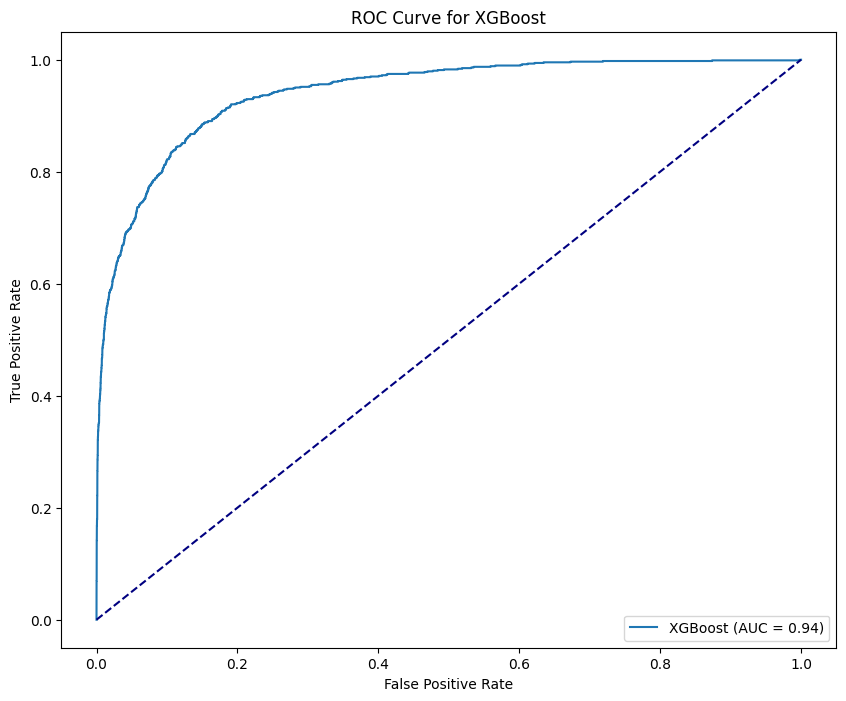

In [55]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir datos para entrenar y validar
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Definir el modelo de XGBoost con GridSearch y L2 Regularization (lambda)
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss')

# Definir la búsqueda de hiperparámetros con los rangos especificados
param_grid = {
    'learning_rate': np.arange(0.05, 0.26, 0.1),  # De 0.05 a 0.25 con paso de 0.1
    'reg_lambda': np.arange(3, 5.1, 0.1),  # De 3 a 5 con paso de 0.1
    'n_estimators': list(range(180, 211, 1))  # De 180 a 210 con paso de 1
}

# Cross-validation con 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, scoring='neg_log_loss', cv=cv)
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo y sus parámetros
best_xgb = grid_search.best_estimator_
best_params = grid_search.best_params_

# Mostrar los mejores parámetros encontrados
print("Mejores parámetros:", best_params)

# Predicción en el conjunto de validación
y_val_proba = best_xgb.predict_proba(X_val)[:, 1]
y_val_pred = best_xgb.predict(X_val)

# Cálculo de la métrica log loss
log_loss_val = log_loss(y_val, y_val_proba)
print(f"Log Loss: {log_loss_val:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_val, y_val_pred)
print("Matriz de confusión:")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy: {accuracy:.4f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

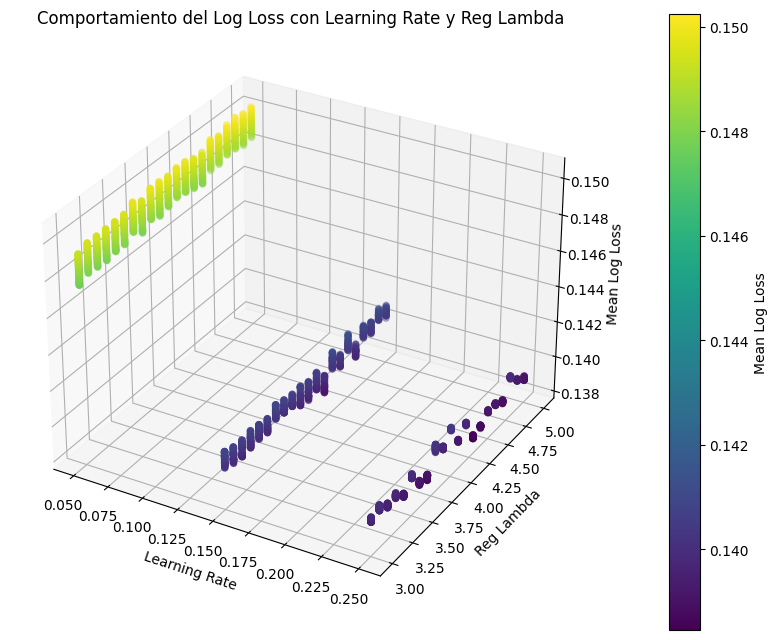

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extraer los resultados del GridSearchCV
cv_results = grid_search.cv_results_

# Crear un DataFrame con los parámetros y el log loss para cada combinación
results_df = pd.DataFrame({
    'learning_rate': cv_results['param_learning_rate'].data,
    'reg_lambda': cv_results['param_reg_lambda'].data,
    'n_estimators': cv_results['param_n_estimators'].data,
    'mean_log_loss': -cv_results['mean_test_score']  # Convertir a log loss positivo
})

# Gráfica 3D de los hiperparámetros y el log loss
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Crear la gráfica de dispersión 3D
sc = ax.scatter(results_df['learning_rate'], results_df['reg_lambda'], results_df['mean_log_loss'], 
                c=results_df['mean_log_loss'], cmap='viridis', marker='o')

# Etiquetas de los ejes
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Reg Lambda')
ax.set_zlabel('Mean Log Loss')

# Añadir barra de colores
cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('Mean Log Loss')

# Título
plt.title('Comportamiento del Log Loss con Learning Rate y Reg Lambda')
plt.show()

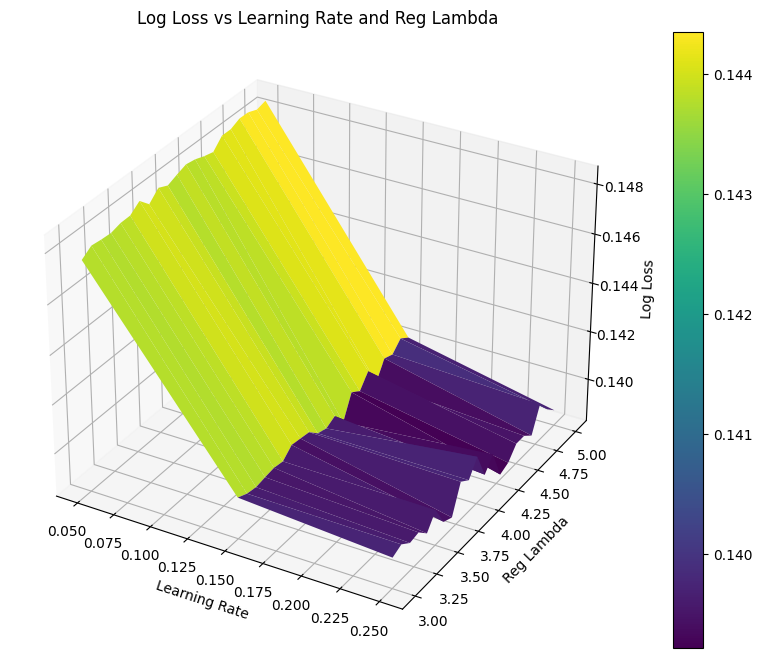

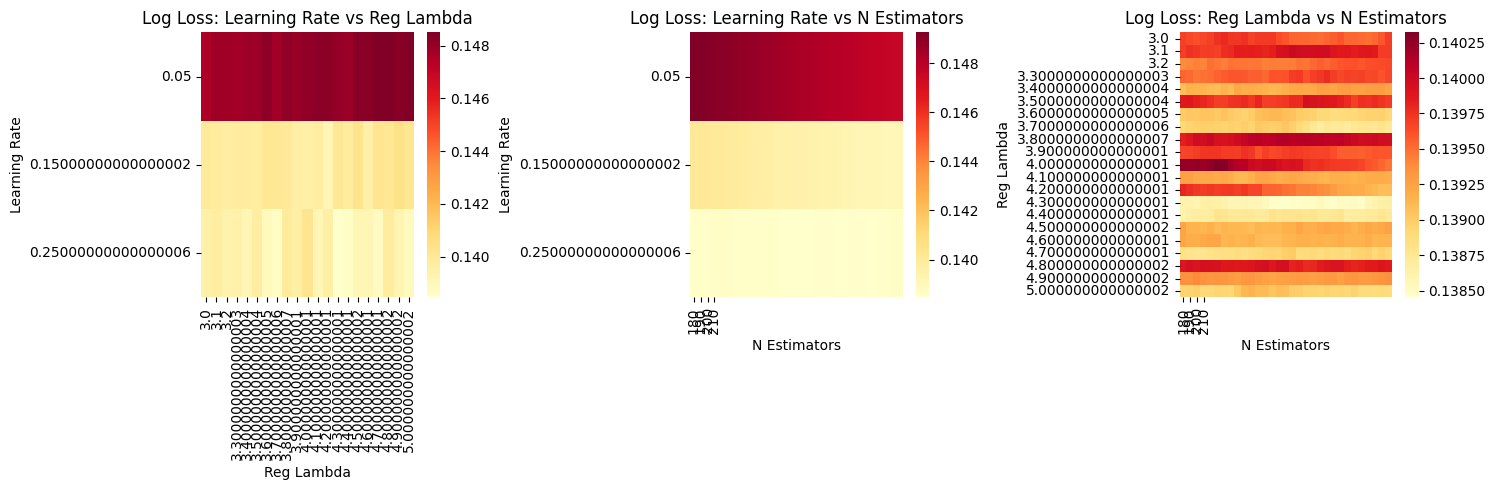

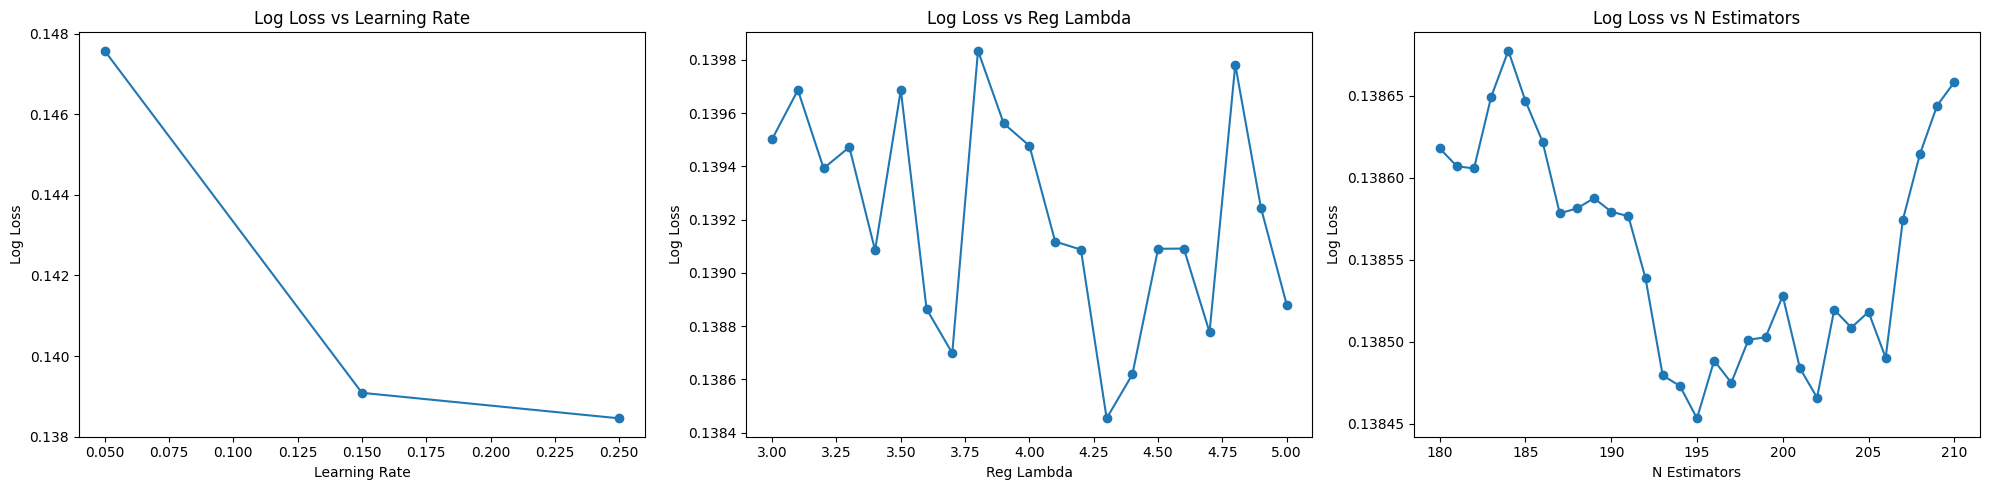

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Asumimos que grid_search es el objeto GridSearchCV que ya has ajustado

# Extraer los resultados
results = grid_search.cv_results_
params = results['params']
scores = results['mean_test_score']

# Convertir scores a log loss (GridSearchCV usa neg_log_loss, así que necesitamos invertir el signo)
logloss_scores = -scores

# Extraer los valores únicos de los hiperparámetros
learning_rates = sorted(set([p['learning_rate'] for p in params]))
reg_lambdas = sorted(set([p['reg_lambda'] for p in params]))
n_estimators = sorted(set([p['n_estimators'] for p in params]))

# 1. Gráfico de superficie 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(learning_rates, reg_lambdas)
Z = np.zeros_like(X)

for i, lr in enumerate(learning_rates):
    for j, reg in enumerate(reg_lambdas):
        Z[j, i] = min([logloss_scores[k] for k, p in enumerate(params) 
                       if p['learning_rate'] == lr and p['reg_lambda'] == reg])

surf = ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Reg Lambda')
ax.set_zlabel('Log Loss')
ax.set_title('Log Loss vs Learning Rate and Reg Lambda')
fig.colorbar(surf)
plt.show()

# 2. Heatmaps
plt.figure(figsize=(15, 5))

# Learning Rate vs Reg Lambda
plt.subplot(131)
heatmap_data = np.zeros((len(learning_rates), len(reg_lambdas)))
for i, lr in enumerate(learning_rates):
    for j, reg in enumerate(reg_lambdas):
        heatmap_data[i, j] = min([logloss_scores[k] for k, p in enumerate(params) 
                                  if p['learning_rate'] == lr and p['reg_lambda'] == reg])
sns.heatmap(heatmap_data, xticklabels=reg_lambdas, yticklabels=learning_rates, cmap='YlOrRd')
plt.xlabel('Reg Lambda')
plt.ylabel('Learning Rate')
plt.title('Log Loss: Learning Rate vs Reg Lambda')

# Learning Rate vs N Estimators
plt.subplot(132)
heatmap_data = np.zeros((len(learning_rates), len(n_estimators)))
for i, lr in enumerate(learning_rates):
    for j, n in enumerate(n_estimators):
        heatmap_data[i, j] = min([logloss_scores[k] for k, p in enumerate(params) 
                                  if p['learning_rate'] == lr and p['n_estimators'] == n])
sns.heatmap(heatmap_data, xticklabels=n_estimators[::10], yticklabels=learning_rates, cmap='YlOrRd')
plt.xlabel('N Estimators')
plt.ylabel('Learning Rate')
plt.title('Log Loss: Learning Rate vs N Estimators')

# Reg Lambda vs N Estimators
plt.subplot(133)
heatmap_data = np.zeros((len(reg_lambdas), len(n_estimators)))
for i, reg in enumerate(reg_lambdas):
    for j, n in enumerate(n_estimators):
        heatmap_data[i, j] = min([logloss_scores[k] for k, p in enumerate(params) 
                                  if p['reg_lambda'] == reg and p['n_estimators'] == n])
sns.heatmap(heatmap_data, xticklabels=n_estimators[::10], yticklabels=reg_lambdas, cmap='YlOrRd')
plt.xlabel('N Estimators')
plt.ylabel('Reg Lambda')
plt.title('Log Loss: Reg Lambda vs N Estimators')

plt.tight_layout()
plt.show()

# 3. Gráficos de línea
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# Learning Rate
lr_scores = [min([logloss_scores[k] for k, p in enumerate(params) if p['learning_rate'] == lr]) for lr in learning_rates]
ax1.plot(learning_rates, lr_scores, marker='o')
ax1.set_xlabel('Learning Rate')
ax1.set_ylabel('Log Loss')
ax1.set_title('Log Loss vs Learning Rate')

# Reg Lambda
reg_scores = [min([logloss_scores[k] for k, p in enumerate(params) if p['reg_lambda'] == reg]) for reg in reg_lambdas]
ax2.plot(reg_lambdas, reg_scores, marker='o')
ax2.set_xlabel('Reg Lambda')
ax2.set_ylabel('Log Loss')
ax2.set_title('Log Loss vs Reg Lambda')

# N Estimators
n_scores = [min([logloss_scores[k] for k, p in enumerate(params) if p['n_estimators'] == n]) for n in n_estimators]
ax3.plot(n_estimators, n_scores, marker='o')
ax3.set_xlabel('N Estimators')
ax3.set_ylabel('Log Loss')
ax3.set_title('Log Loss vs N Estimators')

plt.tight_layout()
plt.show()

## Nuevo intento - 2024 10 20 - 0803

Se probarán 1331 combinaciones de hiperparámetros.
Probando combinación 1/1331: learning_rate=0.2, reg_lambda=4.0, n_estimators=190
Log Loss para esta combinación: 0.1384

Probando combinación 2/1331: learning_rate=0.2, reg_lambda=4.0, n_estimators=191
Log Loss para esta combinación: 0.1383

Probando combinación 3/1331: learning_rate=0.2, reg_lambda=4.0, n_estimators=192
Log Loss para esta combinación: 0.1384

Probando combinación 4/1331: learning_rate=0.2, reg_lambda=4.0, n_estimators=193
Log Loss para esta combinación: 0.1384

Probando combinación 5/1331: learning_rate=0.2, reg_lambda=4.0, n_estimators=194
Log Loss para esta combinación: 0.1383

Probando combinación 6/1331: learning_rate=0.2, reg_lambda=4.0, n_estimators=195
Log Loss para esta combinación: 0.1382

Probando combinación 7/1331: learning_rate=0.2, reg_lambda=4.0, n_estimators=196
Log Loss para esta combinación: 0.1382

Probando combinación 8/1331: learning_rate=0.2, reg_lambda=4.0, n_estimators=197
Log Loss para esta co

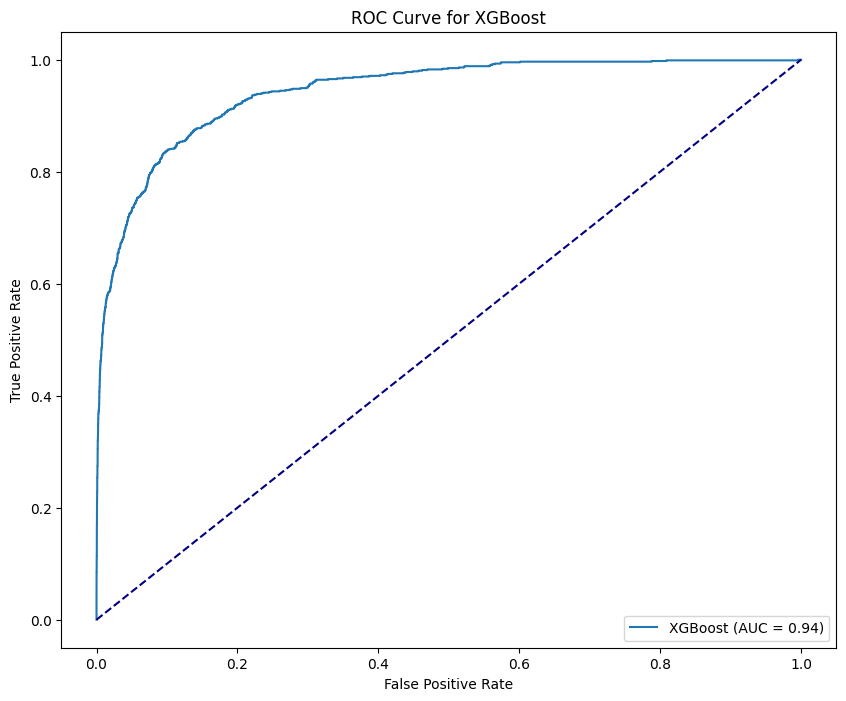

In [63]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt
from itertools import product

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir datos para entrenar y validar
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Definir los rangos de hiperparámetros
param_grid = {
    'learning_rate': np.arange(0.2, 0.31, 0.01),  # De 0.2 a 0.3 con paso de 0.01
    'reg_lambda': np.arange(4.0, 4.51, 0.05),  # De 4 a 4.5 con paso de 0.05
    'n_estimators': list(range(190, 201, 1))  # De 190 a 200 con paso de 1
}

# Obtener todas las combinaciones de hiperparámetros
param_combinations = list(product(param_grid['learning_rate'], param_grid['reg_lambda'], param_grid['n_estimators']))

# Contar el número de combinaciones de hiperparámetros
total_combinations = len(param_combinations)
print(f"Se probarán {total_combinations} combinaciones de hiperparámetros.")

best_log_loss = float('inf')
best_params = None
progress = 0

# Probar cada combinación de hiperparámetros sin validación cruzada
for learning_rate, reg_lambda, n_estimators in param_combinations:
    progress += 1
    print(f"Probando combinación {progress}/{total_combinations}: "
          f"learning_rate={learning_rate}, reg_lambda={reg_lambda}, n_estimators={n_estimators}")

    # Definir el modelo con los hiperparámetros actuales
    xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        learning_rate=learning_rate,
        reg_lambda=reg_lambda,
        n_estimators=n_estimators
    )

    # Entrenar el modelo
    xgb_model.fit(X_train, y_train)

    # Predicción en el conjunto de validación
    y_val_proba = xgb_model.predict_proba(X_val)[:, 1]

    # Cálculo de la métrica log loss
    log_loss_val = log_loss(y_val, y_val_proba)

    # Verificar si es el mejor modelo
    if log_loss_val < best_log_loss:
        best_log_loss = log_loss_val
        best_params = {
            'learning_rate': learning_rate,
            'reg_lambda': reg_lambda,
            'n_estimators': n_estimators
        }

    print(f"Log Loss para esta combinación: {log_loss_val:.4f}\n")

# Mostrar los mejores hiperparámetros y el mejor log_loss
print(f"Mejores parámetros encontrados: {best_params}")
print(f"Mejor Log Loss: {best_log_loss:.4f}")

# Entrenar el mejor modelo con los mejores hiperparámetros
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=best_params['learning_rate'],
    reg_lambda=best_params['reg_lambda'],
    n_estimators=best_params['n_estimators']
)

xgb_model.fit(X_train, y_train)

# Predicción final en el conjunto de validación
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred = xgb_model.predict(X_val)

# Cálculo de la métrica log loss
log_loss_val = log_loss(y_val, y_val_proba)
print(f"Log Loss final con los mejores hiperparámetros: {log_loss_val:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_val, y_val_pred)
print("Matriz de confusión:")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy: {accuracy:.4f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

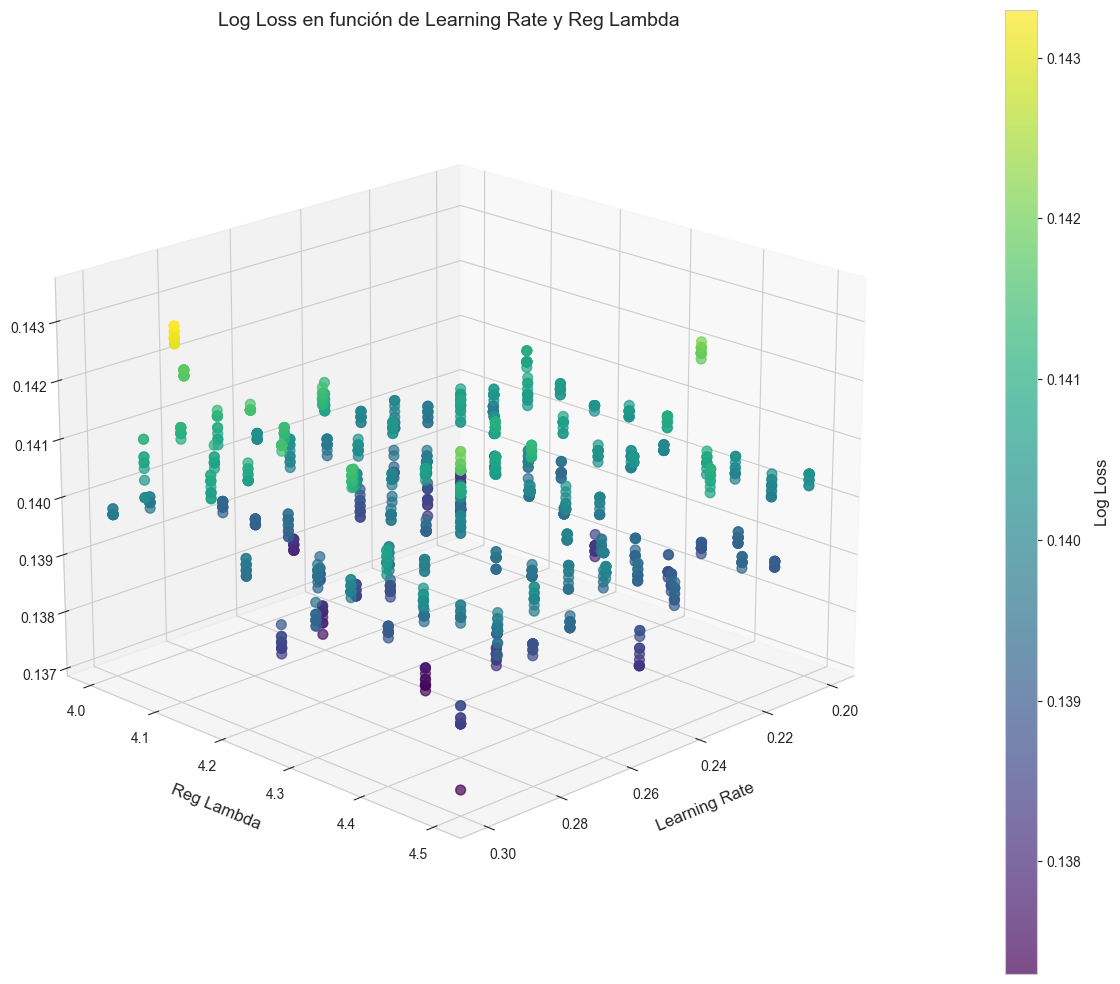

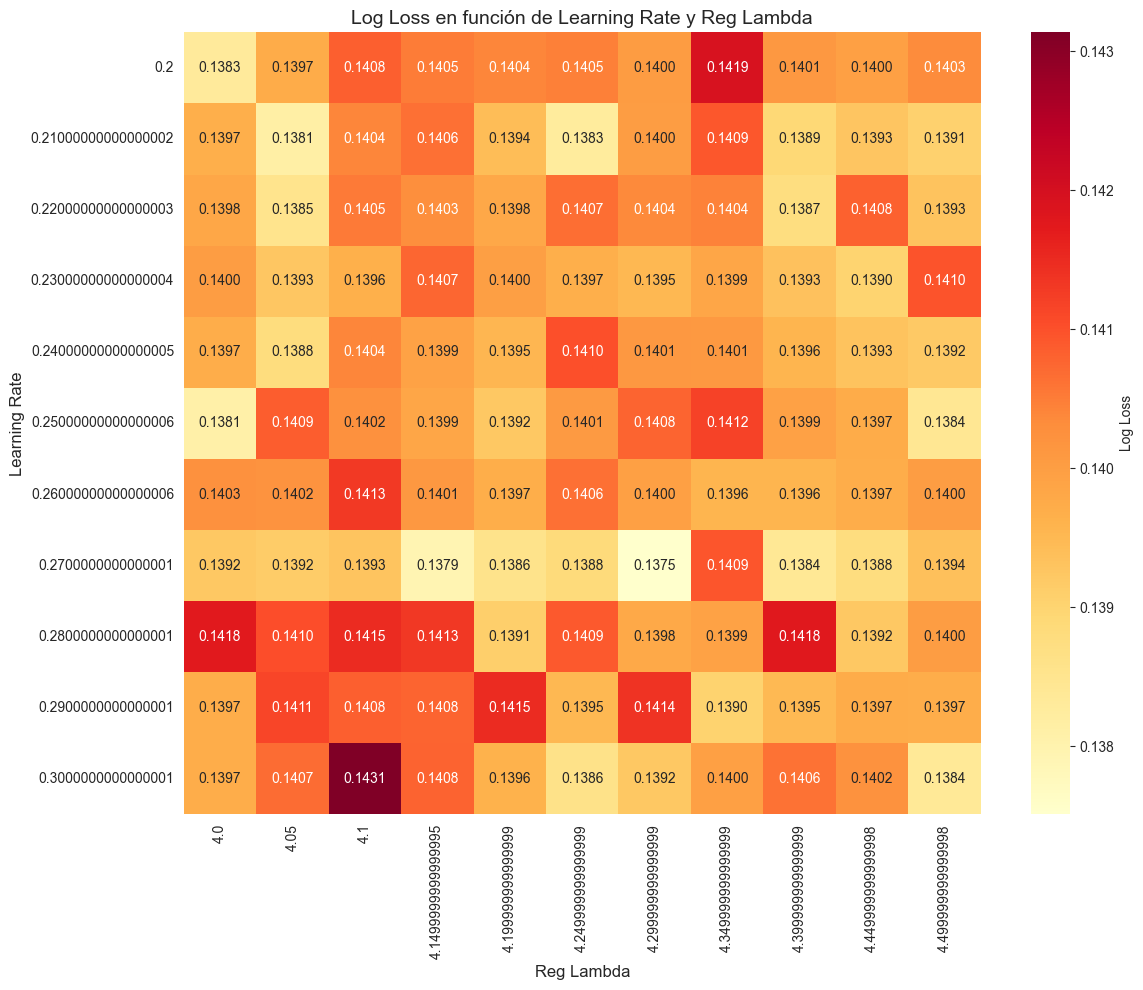

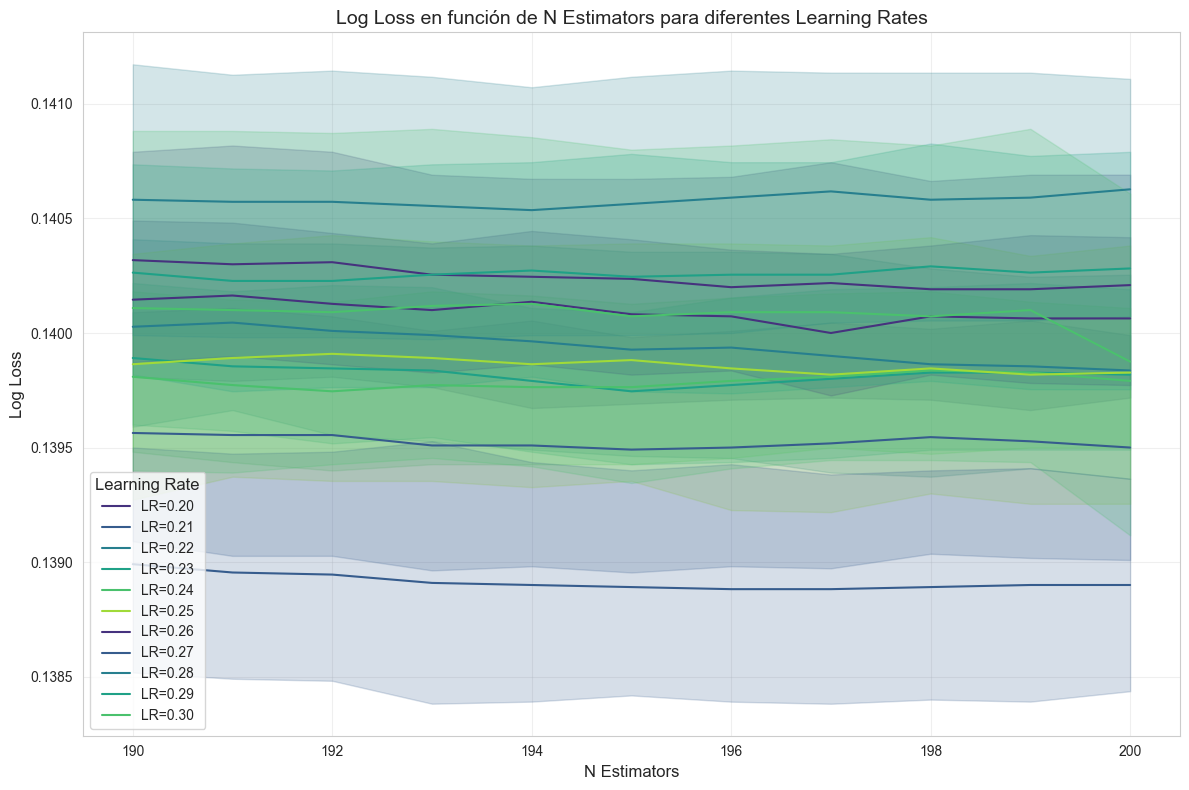

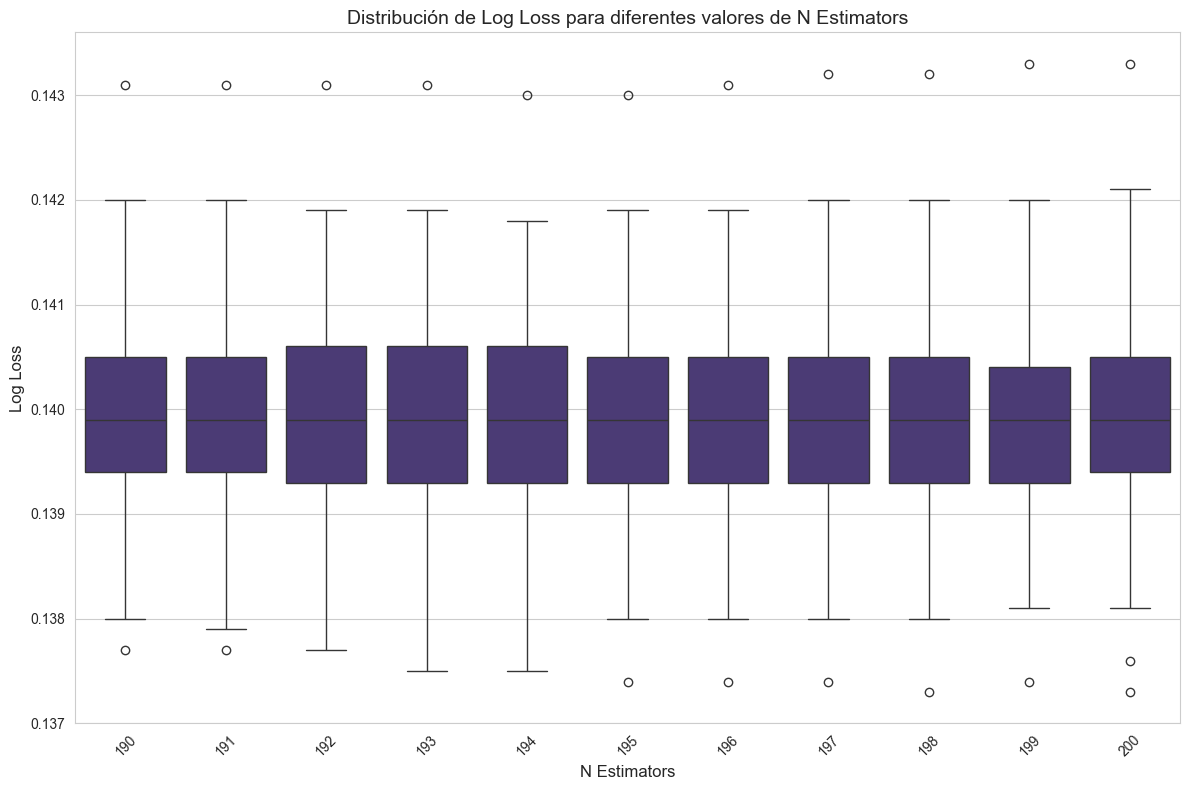

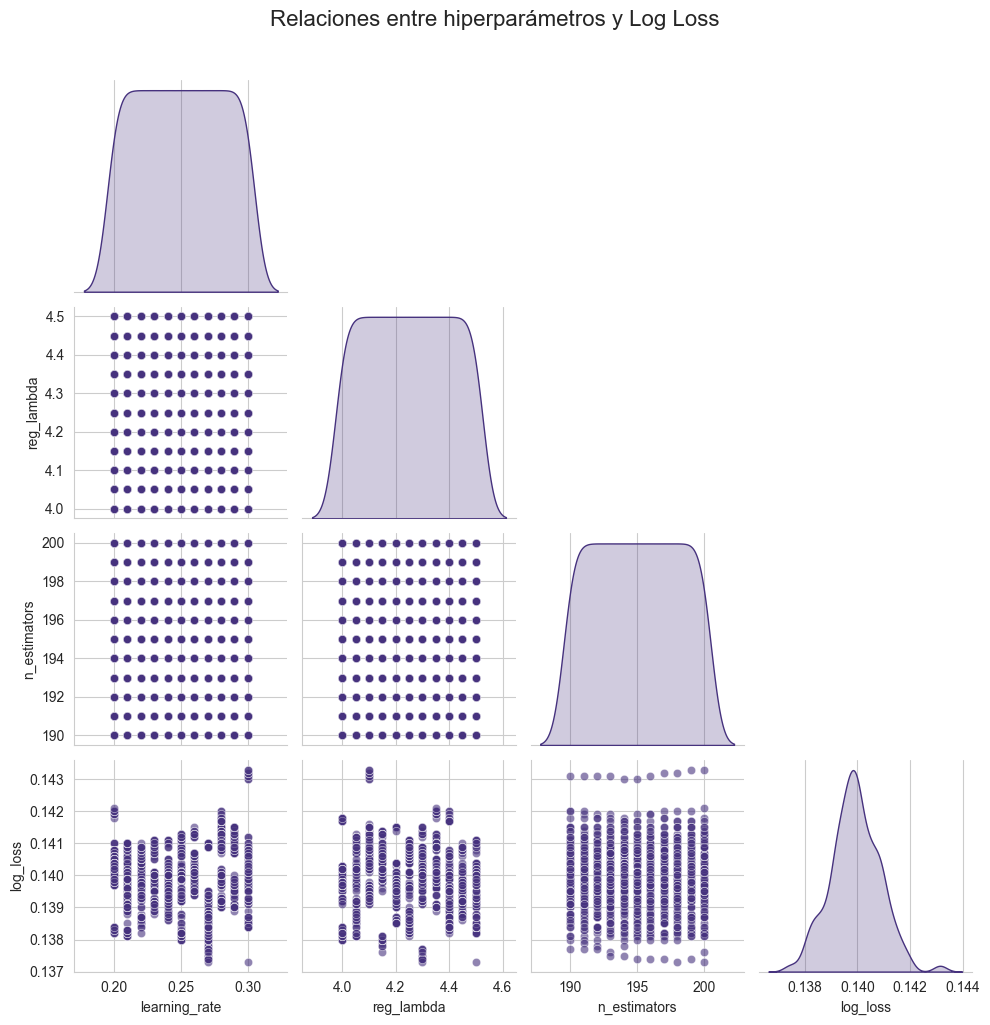


Mejores hiperparámetros encontrados:
Learning Rate: 0.2700
Reg Lambda: 4.3000
N Estimators: 198.0
Log Loss: 0.1373


In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Función para leer y procesar los resultados del archivo de texto (sin cambios)
def process_results(file_path):
    data = {
        'learning_rate': [],
        'reg_lambda': [],
        'n_estimators': [],
        'log_loss': []
    }

    with open(file_path, 'r') as file:
        lines = file.readlines()
        for line in lines:
            if line.startswith('Probando combinación'):
                parts = line.split(': ')[1].split(',')
                lr = float(parts[0].split('=')[1])
                reg_lambda = float(parts[1].split('=')[1])
                n_estimators = int(parts[2].split('=')[1])
            elif line.startswith('Log Loss'):
                log_loss_val = float(line.split(': ')[1])
                data['learning_rate'].append(lr)
                data['reg_lambda'].append(reg_lambda)
                data['n_estimators'].append(n_estimators)
                data['log_loss'].append(log_loss_val)

    return pd.DataFrame(data)

# Leer el archivo de resultados
file_path = 'resultados.txt'  # Asegúrate de ajustar esta ruta al archivo correcto
results_df = process_results(file_path)

# Configuración del estilo de seaborn
sns.set_style("whitegrid")
sns.set_palette("viridis")

# Visualización 1: Gráfica 3D mejorada de learning_rate, reg_lambda y log_loss
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(results_df['learning_rate'], 
                     results_df['reg_lambda'], 
                     results_df['log_loss'], 
                     c=results_df['log_loss'], 
                     cmap='viridis', 
                     s=50, 
                     alpha=0.7)

ax.set_xlabel('Learning Rate', fontsize=12, labelpad=10)
ax.set_ylabel('Reg Lambda', fontsize=12, labelpad=10)
ax.set_zlabel('Log Loss', fontsize=12, labelpad=10)

cbar = fig.colorbar(scatter, ax=ax, pad=0.1, aspect=30)
cbar.set_label('Log Loss', fontsize=12, labelpad=10)

ax.set_title('Log Loss en función de Learning Rate y Reg Lambda', fontsize=14, pad=20)

# Rotar la vista para una mejor perspectiva
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

# Visualización 2: Heatmap de Log Loss en función de Learning Rate y Reg Lambda
plt.figure(figsize=(12, 10))
pivot_table = results_df.pivot_table(values='log_loss', 
                                     index='learning_rate', 
                                     columns='reg_lambda', 
                                     aggfunc='mean')

sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlOrRd', cbar_kws={'label': 'Log Loss'})
plt.title('Log Loss en función de Learning Rate y Reg Lambda', fontsize=14)
plt.xlabel('Reg Lambda', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.tight_layout()
plt.show()

# Visualización 3: Gráfica de líneas mejorada de n_estimators y log_loss
plt.figure(figsize=(12, 8))

for lr in sorted(results_df['learning_rate'].unique()):
    subset = results_df[results_df['learning_rate'] == lr]
    sns.lineplot(x='n_estimators', y='log_loss', data=subset, label=f'LR={lr:.2f}')

plt.xlabel('N Estimators', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Log Loss en función de N Estimators para diferentes Learning Rates', fontsize=14)
plt.legend(title='Learning Rate', title_fontsize='12', fontsize='10')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualización 4: Box plot de Log Loss para diferentes valores de N Estimators
plt.figure(figsize=(12, 8))
sns.boxplot(x='n_estimators', y='log_loss', data=results_df)
plt.xlabel('N Estimators', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Distribución de Log Loss para diferentes valores de N Estimators', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualización 5: Pair plot para todas las variables
sns.pairplot(results_df, vars=['learning_rate', 'reg_lambda', 'n_estimators', 'log_loss'], 
             corner=True, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Relaciones entre hiperparámetros y Log Loss', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Imprimir los mejores hiperparámetros
best_params = results_df.loc[results_df['log_loss'].idxmin()]
print("\nMejores hiperparámetros encontrados:")
print(f"Learning Rate: {best_params['learning_rate']:.4f}")
print(f"Reg Lambda: {best_params['reg_lambda']:.4f}")
print(f"N Estimators: {best_params['n_estimators']}")
print(f"Log Loss: {best_params['log_loss']:.4f}")

## Intento - 2024 10 20 - 09:45 AM

Log Loss: 0.1353
Matriz de confusión:
[[9634   96]
 [ 417  450]]
Accuracy: 0.9516
AUC: 0.9467


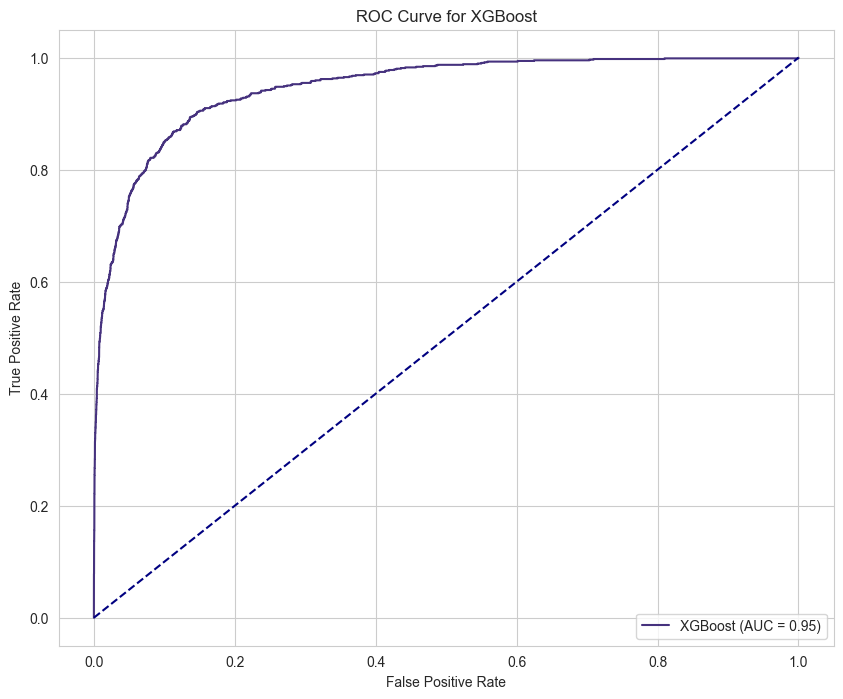

In [202]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir datos para entrenar y validar
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Definir el modelo de XGBoost con los hiperparámetros fijos
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=9,
    learning_rate=0.15,
    reg_lambda=4,
    n_estimators=189
)

# Entrenar el modelo sin validación cruzada
xgb_model.fit(X_train, y_train)

# Predicción en el conjunto de validación
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred = xgb_model.predict(X_val)

# Cálculo de la métrica log loss
log_loss_val = log_loss(y_val, y_val_proba)
print(f"Log Loss: {log_loss_val:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_val, y_val_pred)
print("Matriz de confusión:")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy: {accuracy:.4f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

## Verificar con Cross Validation el Mejor

Log Loss (CV): 0.132028
Matriz de confusión (CV):
[[48146   501]
 [ 2025  2309]]
Accuracy (CV): 0.952323
AUC (CV): 0.948269


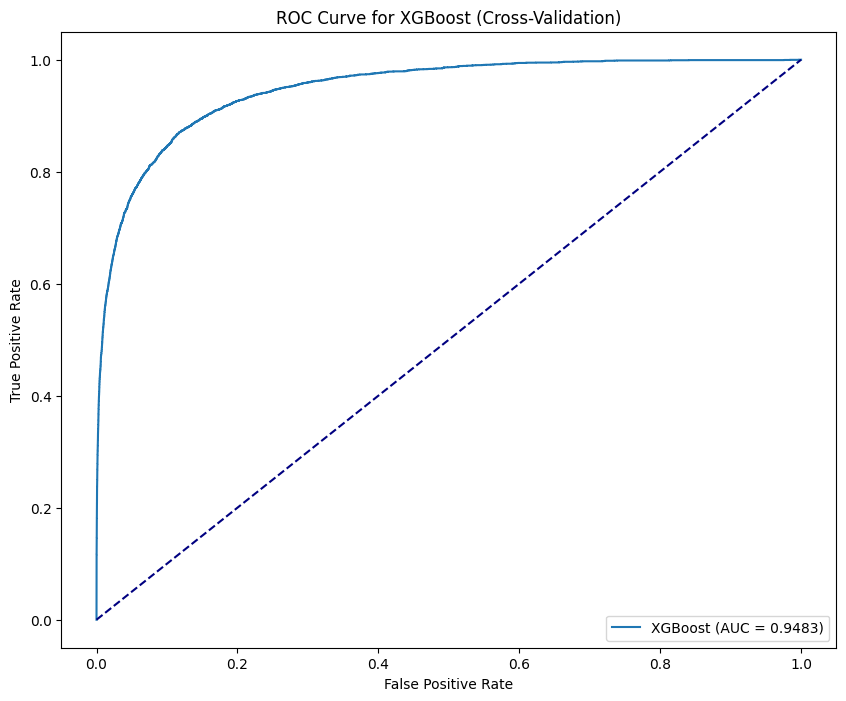

In [1]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Definir el modelo de XGBoost con los hiperparámetros fijos
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=9,
    learning_rate=0.15,
    reg_lambda=4,
    n_estimators=190
)

# Definir la validación cruzada con StratifiedKFold (5 folds)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Realizar predicciones con validación cruzada
y_pred_proba_cv = cross_val_predict(xgb_model, X, y, cv=cv, method='predict_proba')[:, 1]
y_pred_cv = cross_val_predict(xgb_model, X, y, cv=cv)

# Cálculo de las métricas usando validación cruzada
log_loss_cv = log_loss(y, y_pred_proba_cv)
print(f"Log Loss (CV): {log_loss_cv:.6f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y, y_pred_cv)
print("Matriz de confusión (CV):")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y, y_pred_cv)
print(f"Accuracy (CV): {accuracy:.6f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y, y_pred_proba_cv)
roc_auc = auc(fpr, tpr)
print(f"AUC (CV): {roc_auc:.6f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost (Cross-Validation)')
plt.legend(loc='lower right')
plt.show()

## Verificar con Cross Validation el otro mejor

Log Loss (CV): 0.136823
Matriz de confusión (CV):
[[48061   586]
 [ 1935  2399]]
Accuracy (CV): 0.952417
AUC (CV): 0.946684


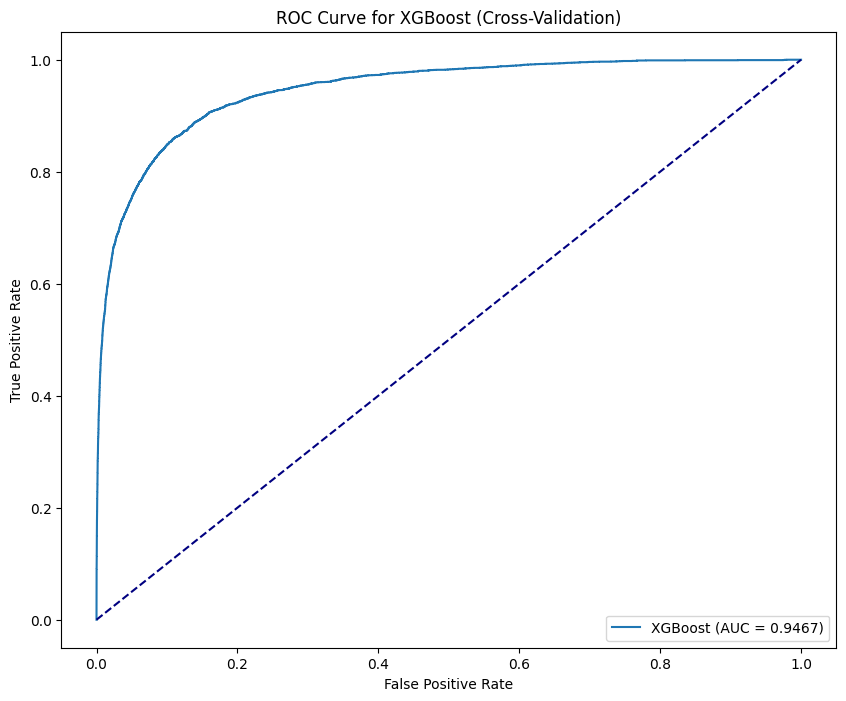

In [2]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Definir el modelo de XGBoost con los hiperparámetros fijos
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=9,
    learning_rate=0.27,
    reg_lambda=4.3,
    n_estimators=194
)

# Definir la validación cruzada con StratifiedKFold (5 folds)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Realizar predicciones con validación cruzada
y_pred_proba_cv = cross_val_predict(xgb_model, X, y, cv=cv, method='predict_proba')[:, 1]
y_pred_cv = cross_val_predict(xgb_model, X, y, cv=cv)

# Cálculo de las métricas usando validación cruzada
log_loss_cv = log_loss(y, y_pred_proba_cv)
print(f"Log Loss (CV): {log_loss_cv:.6f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y, y_pred_cv)
print("Matriz de confusión (CV):")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y, y_pred_cv)
print(f"Accuracy (CV): {accuracy:.6f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y, y_pred_proba_cv)
roc_auc = auc(fpr, tpr)
print(f"AUC (CV): {roc_auc:.6f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost (Cross-Validation)')
plt.legend(loc='lower right')
plt.show()